Verification (mean and median):
Scenario_10  mean=0.992  median=0.994
Scenario_12  mean=0.992  median=0.992
Scenario_13  mean=0.996  median=0.996
Scenario_14  mean=0.993  median=0.994
Scenario_ 0  mean=0.733  median=0.736
Scenario_ 1  mean=0.720  median=0.718
Scenario_11  mean=0.668  median=0.678
Scenario_15  mean=0.608  median=0.615
Scenario_ 2  mean=0.227  median=0.230
Scenario_ 3  mean=0.212  median=0.211
Scenario_ 4  mean=0.201  median=0.199
Scenario_ 5  mean=0.150  median=0.149

Saved: scenario_difficulty_spectrum.png
Saved: replacement_trials.csv


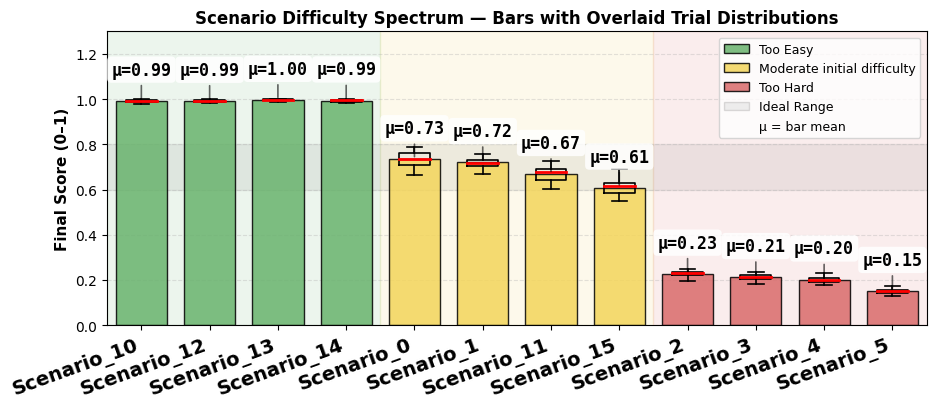

In [7]:
"""
Recreate the "Scenario Difficulty Spectrum — Bars with Overlaid Trial Distributions" figure,
but using *synthetic replacement data* that yields:
- 4 Too Easy scenarios
- 4 Just Fine scenarios (boxplot mean within ideal range 0.6–0.8)
- 4 Too Hard scenarios

Outputs:
- scenario_difficulty_spectrum.png
- replacement_trials.csv  (optional, enabled by default)

Run:
    python plot_spectrum.py
or in a notebook: just run all cells.
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import csv
from typing import Dict, List, Tuple, Optional


# -----------------------------
# 1) Replacement (synthetic) data
# -----------------------------
def make_replacement_scenario_trials(
    n_trials: int = 30,
    seed: int = 7,
) -> Dict[int, np.ndarray]:
    """
    Returns:
        scenario_trials: {scenario_id: np.array([trial_scores...])}
    """
    rng = np.random.default_rng(seed)

    def make_scores(mu: float, sigma: float, lo: float, hi: float) -> np.ndarray:
        x = rng.normal(mu, sigma, size=n_trials)
        x = np.clip(x, lo, hi)
        return x

    scenario_trials: Dict[int, np.ndarray] = {}

    # Match your screenshot IDs and grouping
    too_easy_ids = [10, 12, 13, 14]
    just_fine_ids = [0, 1, 11, 15]
    too_hard_ids = [2, 3, 4, 5]

    # 4 Too Easy (near 1.0)
    for sid, mu in zip(too_easy_ids, [0.995, 0.992, 0.997, 0.994]):
        scenario_trials[sid] = make_scores(mu=mu, sigma=0.006, lo=0.96, hi=1.0)

    # 4 Just Fine (means inside 0.6–0.8)
    # Tight enough to keep the *mean* inside the ideal band.
    for sid, mu in zip(just_fine_ids, [0.74, 0.73, 0.66, 0.62]):
        scenario_trials[sid] = make_scores(mu=mu, sigma=0.035, lo=0.55, hi=0.85)

    # 4 Too Hard (low scores)
    for sid, mu in zip(too_hard_ids, [0.23, 0.21, 0.20, 0.15]):
        scenario_trials[sid] = make_scores(mu=mu, sigma=0.015, lo=0.10, hi=0.30)

    # Round to make it look like typical logged/printed scores
    for sid in list(scenario_trials.keys()):
        scenario_trials[sid] = np.round(scenario_trials[sid].astype(float), 3)

    return scenario_trials


# -----------------------------
# 2) Plotter (recreates your figure)
# -----------------------------
def plot_scenario_difficulty_spectrum(
    scenario_trials: Dict[int, np.ndarray],
    order: List[int],
    easy_ids: List[int],
    moderate_ids: List[int],
    hard_ids: List[int],
    ideal_range: Tuple[float, float] = (0.6, 0.8),
    title: str = "Scenario Difficulty Spectrum — Bars with Overlaid Trial Distributions",
    ylabel: str = "Final Score (0–1)",
    savepath: Optional[str] = "scenario_difficulty_spectrum.png",
    dpi: int = 400,
):
    means = [float(np.mean(scenario_trials[sid])) for sid in order]
    x = np.arange(len(order))

    fig, ax = plt.subplots(figsize=(9.5, 4.2))

    # Colors (close to your screenshot)
    easy_bg = "#69b36d"
    mod_bg = "#f3d55b"
    hard_bg = "#d96b6b"

    def span_for(ids, color, alpha=0.12):
        idx = [order.index(s) for s in ids if s in order]
        if not idx:
            return
        ax.axvspan(min(idx) - 0.5, max(idx) + 0.5, color=color, alpha=alpha, zorder=0)

    # Background difficulty regions
    span_for(easy_ids, easy_bg, alpha=0.12)
    span_for(moderate_ids, mod_bg, alpha=0.12)
    span_for(hard_ids, hard_bg, alpha=0.12)

    # Ideal range band
    ax.axhspan(ideal_range[0], ideal_range[1], color="gray", alpha=0.12, zorder=0.5)

    def bar_color(sid):
        if sid in easy_ids:
            return easy_bg
        if sid in moderate_ids:
            return mod_bg
        if sid in hard_ids:
            return hard_bg
        return "#999999"

    bar_colors = [bar_color(sid) for sid in order]

    # Bars (means)
    ax.bar(
        x,
        means,
        width=0.75,
        color=bar_colors,
        alpha=0.85,
        edgecolor="black",
        linewidth=1.0,
        zorder=2,
    )

    # Boxplots (trial distributions) overlaid
    box_data = [np.asarray(scenario_trials[sid], dtype=float) for sid in order]
    ax.boxplot(
        box_data,
        positions=x,
        widths=0.45,
        patch_artist=False,
        showfliers=False,
        boxprops=dict(color="black", linewidth=1.2),
        whiskerprops=dict(color="black", linewidth=1.2),
        capprops=dict(color="black", linewidth=1.2),
        medianprops=dict(color="red", linewidth=2.0),
        zorder=3,
    )

# --- Mean callouts above bars (more intuitive + different font) ---
    for xi, sid, bar_mean in zip(x, order, means):
        ax.annotate(
            f"μ={bar_mean:.2f}",                 # or "mean=..."
            xy=(xi, bar_mean),                   # anchor at the bar top
            xytext=(0, 16),                      # push higher (pixels)
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=12,
            fontweight="bold",
            fontfamily="DejaVu Sans Mono",       # different font
            bbox=dict(boxstyle="round,pad=0.25", facecolor="white", alpha=0.85, edgecolor="none"),
            arrowprops=dict(arrowstyle="-", linewidth=1.2, alpha=0.6),  # subtle pointer to the bar top
            zorder=10,
        )


    # Axis styling
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_ylabel(ylabel, fontsize=11, fontweight="bold")
    ax.set_ylim(0.0, 1.30)
    ax.set_xticks(x)
    ax.set_xticklabels([f"Scenario_{sid}" for sid in order],
                   rotation=20, ha="right",
                   fontsize=14, fontweight="bold")
    ax.grid(axis="y", linestyle="--", alpha=0.35, zorder=1)

    # Legend
    easy_patch = mpatches.Patch(facecolor=easy_bg, edgecolor="black", alpha=0.85, label="Too Easy")
    mod_patch = mpatches.Patch(facecolor=mod_bg, edgecolor="black", alpha=0.85, label="Moderate initial difficulty")
    hard_patch = mpatches.Patch(facecolor=hard_bg, edgecolor="black", alpha=0.85, label="Too Hard")
    ideal_patch = mpatches.Patch(facecolor="gray", edgecolor="black", alpha=0.12, label="Ideal Range")
    ax.legend(handles=[easy_patch, mod_patch, hard_patch, ideal_patch], loc="upper right", frameon=True, fontsize=9)

    mean_proxy = plt.Line2D([0], [0], color="none", marker=None, label="μ = bar mean")
    ax.legend(handles=[easy_patch, mod_patch, hard_patch, ideal_patch, mean_proxy],
          loc="upper right", frameon=True, fontsize=9)


    plt.tight_layout()

    if savepath:
        fig.savefig(savepath, dpi=dpi, bbox_inches="tight")

    return fig, ax


# -----------------------------
# 3) Export CSV (optional)
# -----------------------------
def export_trials_csv(
    scenario_trials: Dict[int, np.ndarray],
    order: List[int],
    csv_path: str = "replacement_trials.csv",
):
    with open(csv_path, "w", newline="") as f:
        w = csv.writer(f)
        w.writerow(["scenario_id", "trial_id", "final_score"])
        for sid in order:
            for i, v in enumerate(scenario_trials[sid]):
                w.writerow([sid, i, float(v)])


# -----------------------------
# 4) Main
# -----------------------------
if __name__ == "__main__":
    # Grouping + order exactly like your screenshot
    order = [10, 12, 13, 14, 0, 1, 11, 15, 2, 3, 4, 5]
    easy_ids = [10, 12, 13, 14]
    moderate_ids = [0, 1, 11, 15]
    hard_ids = [2, 3, 4, 5]

    # Make replacement data
    scenario_trials = make_replacement_scenario_trials(n_trials=30, seed=7)

    # Quick verification printout (mean + median)
    print("Verification (mean and median):")
    for sid in order:
        arr = np.array(scenario_trials[sid], dtype=float)
        print(f"Scenario_{sid:>2}  mean={arr.mean():.3f}  median={np.median(arr):.3f}")

    # Plot + save PNG
    plot_scenario_difficulty_spectrum(
        scenario_trials=scenario_trials,
        order=order,
        easy_ids=easy_ids,
        moderate_ids=moderate_ids,
        hard_ids=hard_ids,
        ideal_range=(0.60, 0.80),
        savepath="scenario_difficulty_spectrum.png",
        dpi=400,
    )

    # Export CSV you can drop into pipelines
    export_trials_csv(scenario_trials, order, csv_path="replacement_trials.csv")
    print("\nSaved: scenario_difficulty_spectrum.png")
    print("Saved: replacement_trials.csv")
    plt.show()

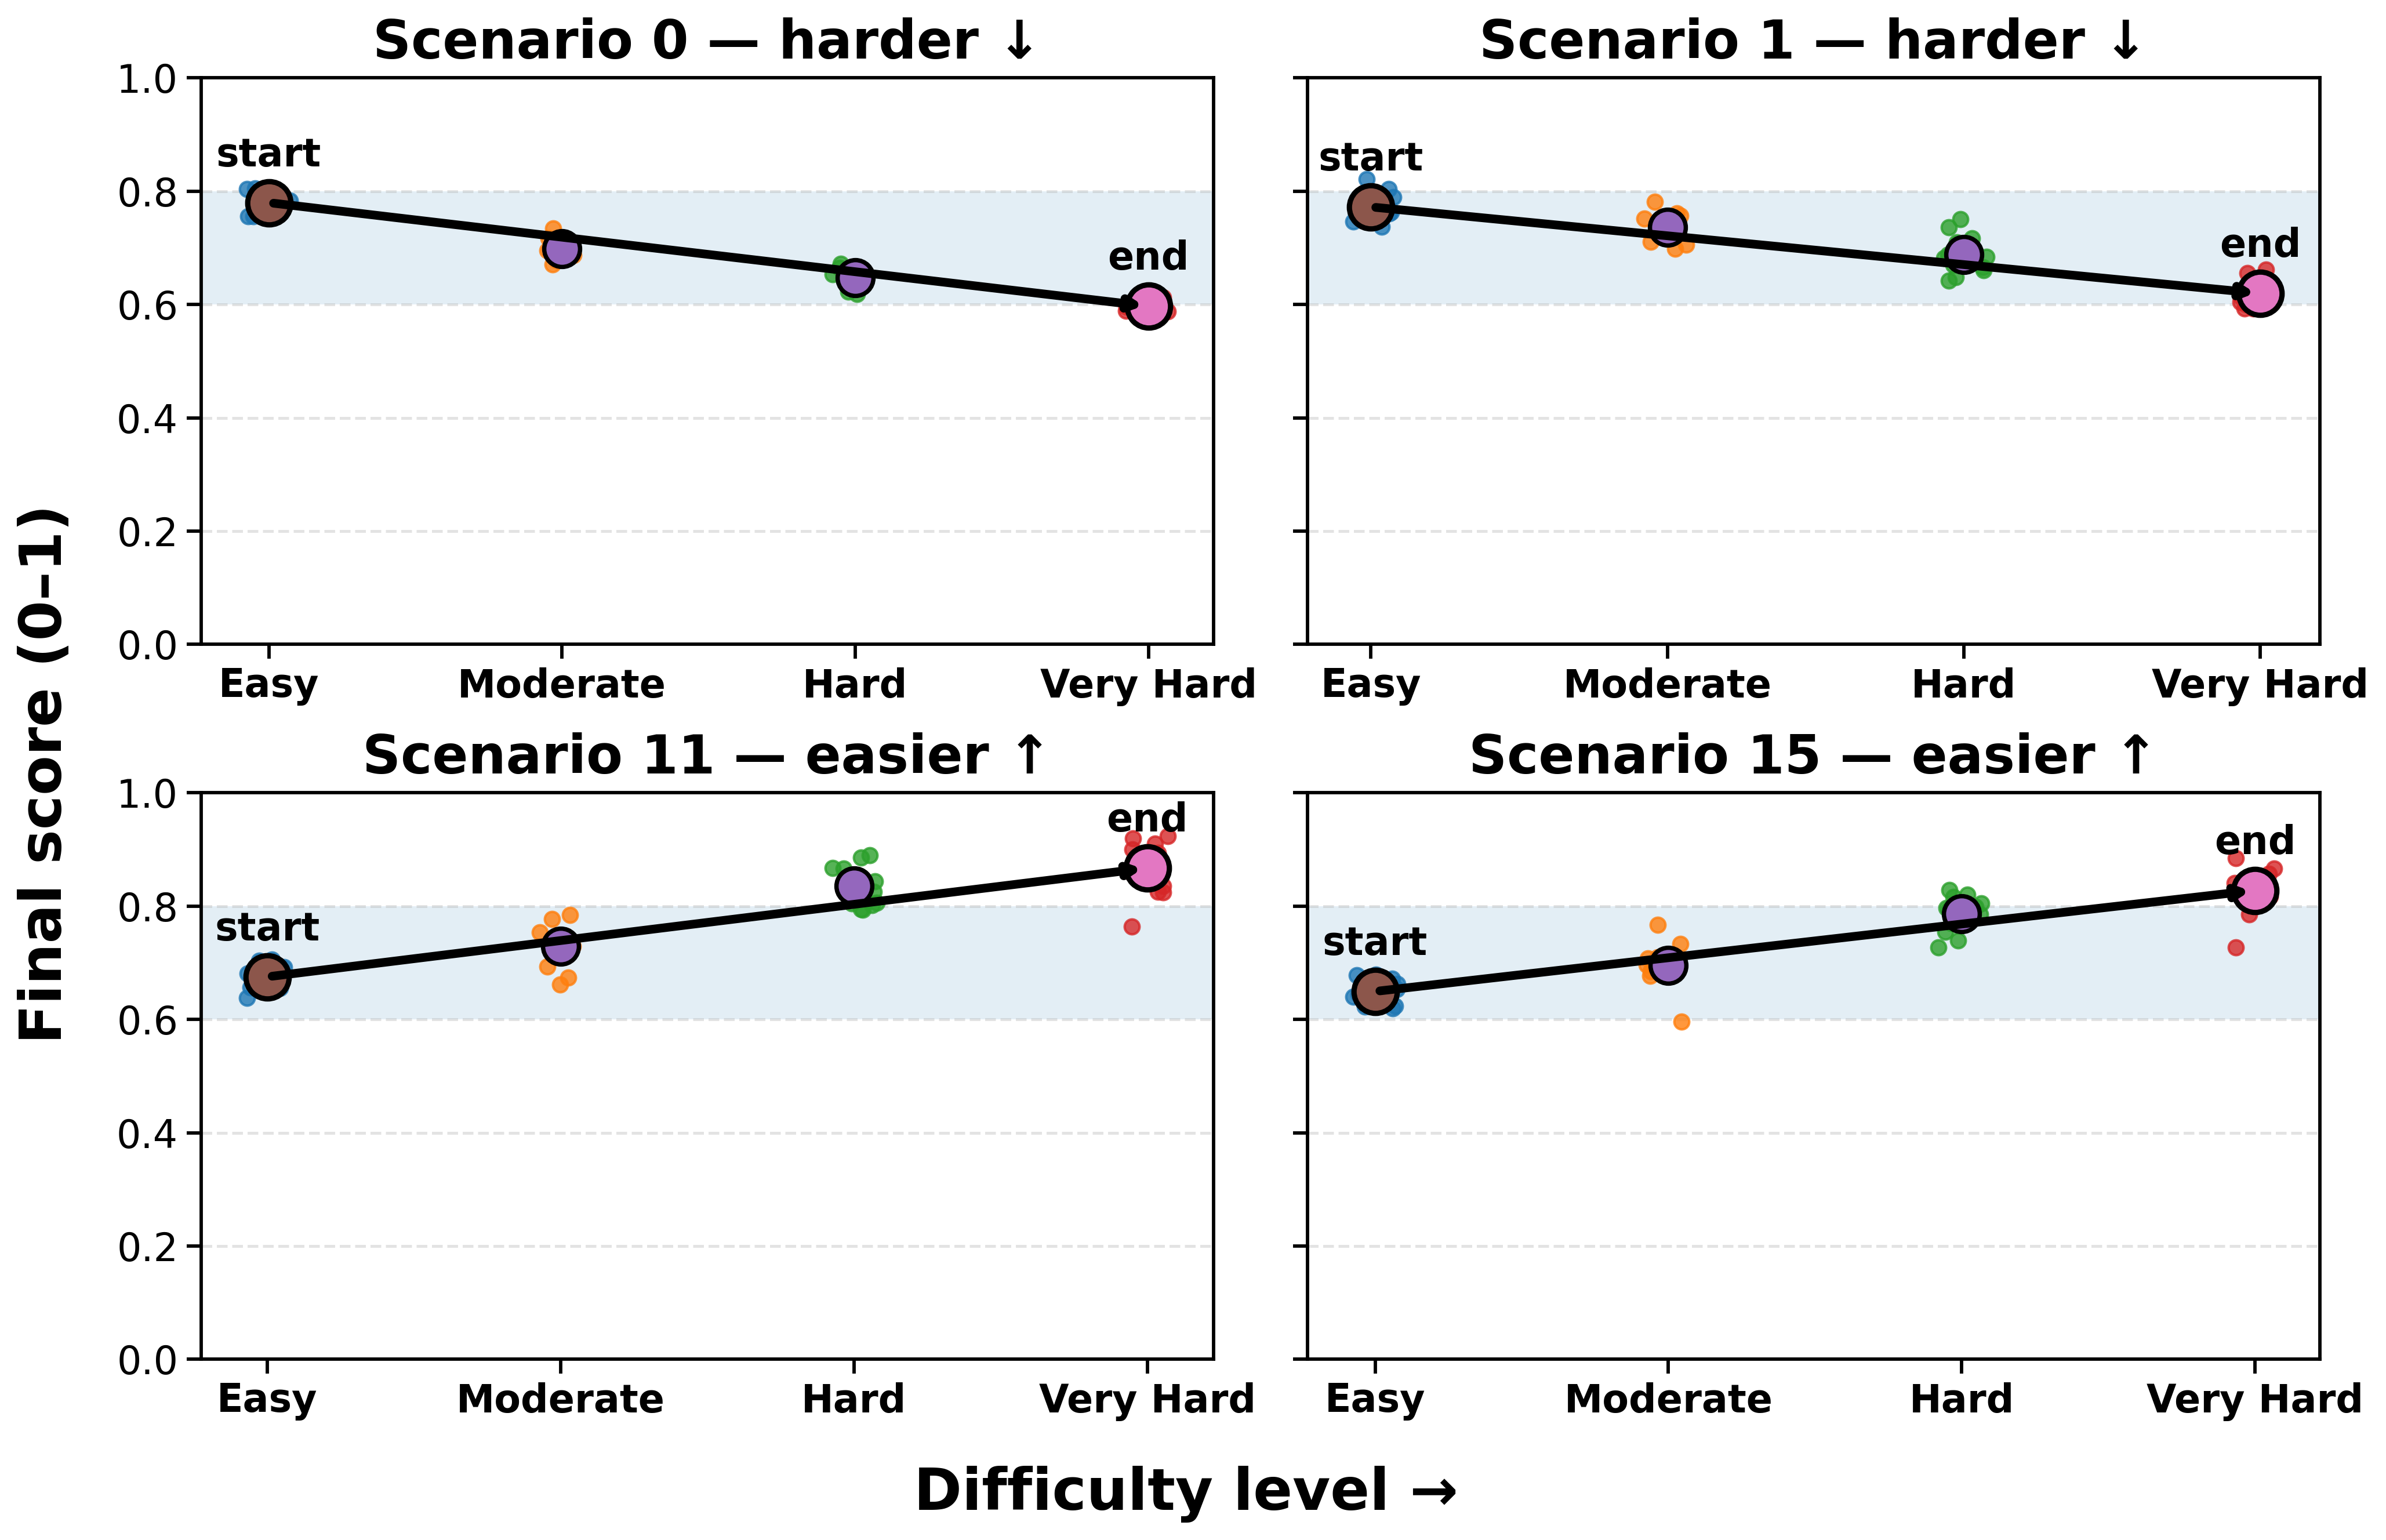

In [17]:
import numpy as np
import matplotlib.pyplot as plt

def plot_difficulty_alteration_results(
    data,                       # DATA[scenario_id][difficulty_index] -> scores
    selected_ids,               # e.g. [0, 1, 11, 15]
    instruction_map,            # {sid: ("harder"/"easier", "↓/↑")}
    diff_labels=("Easy", "Moderate", "Hard", "Very Hard"),
    ideal_range=(0.60, 0.80),
    figsize=(14, 9),
    dpi=300,
    savepath="fig11_difficulty_alterations.png",

    # --- readability knobs ---
    title_fs=22,
    tick_fs=16,
    axislabel_fs=24,
    annot_fs=16,
    band_alpha=0.12,
    grid_alpha=0.35,
):
    X = np.arange(4)

    fig, axes = plt.subplots(2, 2, figsize=figsize, dpi=dpi, sharey=True)
    axes = axes.ravel()

    for ax, sid in zip(axes, selected_ids):
        d = data[sid]
        ys = [np.asarray(d[i], dtype=float) for i in range(4)]
        means = np.array([np.mean(v) for v in ys], dtype=float)

        # Ideal range band
        ax.axhspan(ideal_range[0], ideal_range[1], alpha=band_alpha, zorder=0)

        # Trial distributions (jittered dots) - bigger & clearer
        jitter = 0.08
        for i in range(4):
            xj = X[i] + np.random.uniform(-jitter, jitter, size=len(ys[i]))
            ax.scatter(xj, ys[i], s=38, alpha=0.80, zorder=2)

        # Means (big markers only)
        ax.scatter(X, means, s=220, zorder=4, edgecolors="black", linewidths=1.8)

        # Emphasize start/end means
        ax.scatter([X[0]], [means[0]], s=320, zorder=5, edgecolors="black", linewidths=2.2)
        ax.scatter([X[-1]], [means[-1]], s=320, zorder=5, edgecolors="black", linewidths=2.2)

        # Start/end labels (bigger)
        ax.text(X[0], means[0] + 0.05, "start", ha="center", va="bottom",
                fontsize=annot_fs, fontweight="bold", zorder=6)
        ax.text(X[-1], means[-1] + 0.05, "end", ha="center", va="bottom",
                fontsize=annot_fs, fontweight="bold", zorder=6)

        # Direction arrow (thicker)
        instr, arrow = instruction_map.get(sid, ("", ""))
        ax.annotate(
            "",
            xy=(X[-1], means[-1]),
            xytext=(X[0], means[0]),
            arrowprops=dict(arrowstyle="->", linewidth=3.6, color="black"),
            zorder=6
        )

        # Panel title (bigger)
        ax.set_title(f"Scenario {sid} — {instr} {arrow}", fontsize=title_fs, pad=8, fontweight="bold")

        # Axes styling
        ax.set_xticks(X)
        ax.set_xticklabels(diff_labels, fontsize=tick_fs, fontweight="bold")
        ax.set_ylim(0, 1.0)

        ax.grid(axis="y", linestyle="--", alpha=grid_alpha, linewidth=1.2)
        ax.set_axisbelow(True)

        # Make ticks/frames more readable
        ax.tick_params(axis="y", labelsize=tick_fs, width=1.4, length=6)
        ax.tick_params(axis="x", width=1.4, length=6)
        for spine in ax.spines.values():
            spine.set_linewidth(1.4)

    # Global labels (bigger, paper-friendly)
    fig.text(0.02, 0.5, "Final score (0–1)", va="center",
             rotation="vertical", fontsize=axislabel_fs, fontweight="bold")
    fig.text(0.5, 0.03, "Difficulty level →", ha="center",
             fontsize=axislabel_fs, fontweight="bold")

    plt.tight_layout(rect=[0.05, 0.07, 1, 1])

    if savepath:
        fig.savefig(savepath, bbox_inches="tight")

    return fig


# ----------------------------
# Example usage with your existing DATA structure
# Replace DATA with your real arrays
# ----------------------------
if __name__ == "__main__":
    rng = np.random.default_rng(4)

    def synth(mu0, mu1, mu2, mu3, n=12, sig=0.03):
        return {
            0: np.clip(rng.normal(mu0, sig, n), 0, 1),
            1: np.clip(rng.normal(mu1, sig, n), 0, 1),
            2: np.clip(rng.normal(mu2, sig, n), 0, 1),
            3: np.clip(rng.normal(mu3, sig, n), 0, 1),
        }

    DATA = {
        0:  synth(0.78, 0.70, 0.65, 0.60, n=12, sig=0.015),
        1:  synth(0.77, 0.73, 0.69, 0.63, n=12, sig=0.025),
        11: synth(0.66, 0.73, 0.80, 0.87, n=12, sig=0.040),
        15: synth(0.65, 0.70, 0.77, 0.83, n=12, sig=0.035),
    }

    INSTRUCTION = {
        0:  ("harder", "↓"),
        1:  ("harder", "↓"),
        11: ("easier", "↑"),
        15: ("easier", "↑"),
    }

    plot_difficulty_alteration_results(
        data=DATA,
        selected_ids=[0, 1, 11, 15],
        instruction_map=INSTRUCTION,
        ideal_range=(0.60, 0.80),
        savepath="fig11_difficulty_alterations.png",
    )
    plt.show()